In [1]:
# import packages
from __future__ import annotations
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from causalml.inference.tree import UpliftRandomForestClassifier
import os 
import warnings
from pathlib import Path
import sys
import plotly.graph_objects as go
from scipy.stats import gaussian_kde

pd.options.mode.chained_assignment = None
warnings.simplefilter("ignore")

C:\Users\tsterk\AppData\Local\anaconda3\envs\causalml_py312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Failed to import duecredit due to No module named 'duecredit'


In [2]:
np.random.seed(42)

In [3]:
# import custom functions
PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != "Thesis code" and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

from Functions.data_utils import (
    plot_incremental_response_rate,
    uplift_by_decile_bin,
    coerce_metrics_to_numeric,
)

In [4]:
# load data for training models
file_path = r"Data/covariates_modeling_uplift_models_2026-03-13.csv"
df = pd.read_csv(file_path)

In [5]:
# drop not performing incentives
drop_indicators = [
    "BNLX_ChurnP_SKUd_test_export.csv",
    "BNLX_ChurnP_SKUd_controle_export.csv",
    "BNLX_ChurnP_niks_test_export.csv",
    "BNLX_ChurnP_niks_controle_export.csv",
]

df = df[~df["treatment_indicator"].isin(drop_indicators)]

In [6]:
# convert for easy processing
treatment_converter = {
    "BNLX_ChurnP_10_test_export.csv": "treatment_1",
    "BNLX_ChurnP_10_controle_export.csv": "control_1", 
    
    "BNLX_ChurnP_25_test_export.csv": "treatment_2",
    "BNLX_ChurnP_25_controle_export.csv": "control_2",

    "BNLX_ChurnP_5eu_test_export.csv": "treatment_3",
    "BNLX_ChurnP_5eu_controle_export.csv": "control_3",

    "BNLX_ChurnP_10eu_test_export.csv": "treatment_4",
    "BNLX_ChurnP_10eu_controle_export.csv": "control_4",
    
    "BNLX_ChurnP_250_test_export.csv": "treatment_5",
    "BNLX_ChurnP_250_controle_export.csv": "control_5",

    "BNLX_ChurnP_500_test_export.csv": "treatment_6",
    "BNLX_ChurnP_500_controle_export.csv": "control_6",    

    "BNLX_ChurnP_SKUe_test_export.csv": "treatment_7",
    "BNLX_ChurnP_SKUe_controle_export.csv": "control_7"
}

df["treatment"] = df["treatment_indicator"].map(treatment_converter)
df = df[df["treatment"].notna()]

In [7]:
# Variables for modelling
categorical_cols  = ['has_rfl','gender','country_sk']
numeric_cols = [ 'recency', 'frequency', 'monetary_value',  'total_volume', 'length_of_relationship', 'online_sales', 'retail_sales', 
      'food_total', 'vhms_total', 'sports_total', 'beauty_total', 'frequency_52wk', 'monetary_value_52wk', 'volume_52wk', 'online_sales_52w', 
       'retail_sales_52w', 'frequency_53w_104w', 'monetary_value_53w_104w', 'volume_53w_104w', 'online_sales_53w_104w','retail_sales_53w_104w']

In [8]:
# Fix numeric output
df = coerce_metrics_to_numeric(df, numeric_cols)

df[categorical_cols] = df[categorical_cols].astype("object")
df[numeric_cols] = df[numeric_cols].astype("int64")

In [9]:
(100 * df.groupby('treatment_indicator')['reactivated'].mean()).round(2)

treatment_indicator
BNLX_ChurnP_10_controle_export.csv      1.95
BNLX_ChurnP_10_test_export.csv          2.16
BNLX_ChurnP_10eu_controle_export.csv    2.04
BNLX_ChurnP_10eu_test_export.csv        2.35
BNLX_ChurnP_250_controle_export.csv     2.03
BNLX_ChurnP_250_test_export.csv         2.36
BNLX_ChurnP_25_controle_export.csv      1.99
BNLX_ChurnP_25_test_export.csv          2.20
BNLX_ChurnP_500_controle_export.csv     2.24
BNLX_ChurnP_500_test_export.csv         2.52
BNLX_ChurnP_5eu_controle_export.csv     2.05
BNLX_ChurnP_5eu_test_export.csv         2.47
BNLX_ChurnP_SKUe_controle_export.csv    2.09
BNLX_ChurnP_SKUe_test_export.csv        2.23
Name: reactivated, dtype: float64

In [10]:
# Split for modeling
X = df[numeric_cols + categorical_cols]
y = df['reactivated']
t = df['treatment']

In [11]:
# Train uplift model per incentive for later deployement
def train_full_RF_uplift_store(
    df_train: pd.DataFrame,
    X_train: pd.DataFrame,
    y_train,
    t_train,
    *,
    random_state: int = 42,
    control_name: str = "control_0",
) -> dict:
    """Train on full data """
    y_s = pd.Series(y_train, index=X_train.index)
    t_s = pd.Series(t_train, index=X_train.index)

    categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns
    numeric_cols = X_train.columns.difference(categorical_cols)

    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

    def _prep_cat(X_part: pd.DataFrame) -> pd.DataFrame:
        if len(categorical_cols) == 0:
            return X_part
        return X_part.assign(
            **{c: X_part[c].astype("string").fillna("MISSING") for c in categorical_cols}
        )

    def encode_X(X_part: pd.DataFrame) -> np.ndarray:
        X_part = _prep_cat(X_part)
        X_num = X_part[numeric_cols].to_numpy()
        if len(categorical_cols) == 0:
            return X_num
        X_cat = ohe.transform(X_part[categorical_cols])
        return np.hstack([X_num, X_cat])

    X_train_prep = _prep_cat(X_train)
    if len(categorical_cols) > 0:
        ohe.fit(X_train_prep[categorical_cols])

    X_train_enc = encode_X(X_train)

    uplift_model = UpliftRandomForestClassifier(control_name=control_name, n_estimators= 100, random_state=random_state)
    uplift_model.fit(
        X_train_enc,
        treatment=t_s.astype(str).values,
        y=y_s.astype(int).values,
    )

    return {
        "model": uplift_model,
        "ohe": ohe,
        "categorical_cols": categorical_cols,
        "numeric_cols": numeric_cols,
        "control_name": control_name,
    }


# Train and store 7 models
trained_models: dict[int, dict] = {}

for k in range(1, 8):
    mask = t.isin([f"treatment_{k}", f"control_{k}"])
    if not mask.any():
        continue
    trained_models[k] = train_full_RF_uplift_store(
        df_train=df.loc[mask],
        X_train=X.loc[mask],
        y_train=y.loc[mask],
        t_train=t.loc[mask],
        control_name=f"control_{k}",
    )
    print(f"Trained model for experiment {k}")

Trained model for experiment 1
Trained model for experiment 2
Trained model for experiment 3
Trained model for experiment 4
Trained model for experiment 5
Trained model for experiment 6
Trained model for experiment 7


## Deployement dataset

In [12]:
# get the data for the binary uplift models
# taking half so the other half is preserved for the MTUM
active_treatments = [1, 2, 3, 4, 5, 6, 7]  

file_path_2 = r"Data/covariates_deployment_dataset_2026-03-17.csv"
df_half_2 = pd.read_csv(file_path_2)
df_half_2_shuffled = df_half_2.sample(frac=0.5, random_state=42)
n = len(df_half_2_shuffled)
chunk = n // 7

experiment_samples = {
    t: df_half_2_shuffled.iloc[i*chunk : (i+1)*chunk]
    for i, t in enumerate(active_treatments)
}

print({k: len(v) for k, v in experiment_samples.items()})

{1: 19801, 2: 19801, 3: 19801, 4: 19801, 5: 19801, 6: 19801, 7: 19801}


In [13]:
for k, df_k in experiment_samples.items():
    experiment_samples[k] = coerce_metrics_to_numeric(df_k, numeric_cols)
    experiment_samples[k][categorical_cols] = experiment_samples[k][categorical_cols].astype("object")
    experiment_samples[k][numeric_cols] = experiment_samples[k][numeric_cols].astype("int64")

In [14]:
def predict_uplift(
    artifacts: dict,
    df_test: pd.DataFrame,
    X_test: pd.DataFrame,
) -> pd.DataFrame:
    ohe = artifacts["ohe"]
    categorical_cols = artifacts["categorical_cols"]
    numeric_cols = artifacts["numeric_cols"]

    def _prep_cat(X_part: pd.DataFrame) -> pd.DataFrame:
        if len(categorical_cols) == 0:
            return X_part
        return X_part.assign(
            **{c: X_part[c].astype("string").fillna("MISSING") for c in categorical_cols}
        )

    def encode_X(X_part: pd.DataFrame) -> np.ndarray:
        X_part = _prep_cat(X_part)
        X_num = X_part[numeric_cols].to_numpy()
        if len(categorical_cols) == 0:
            return X_num
        X_cat = ohe.transform(X_part[categorical_cols])
        return np.hstack([X_num, X_cat])

    X_test_enc = encode_X(X_test)

    uplift_pred = np.asarray(artifacts["model"].predict(X_test_enc))
    cate = uplift_pred if uplift_pred.ndim == 1 else uplift_pred.max(axis=1)

    result_df = df_test.loc[X_test.index].copy()
    result_df["cate"] = cate
    return result_df


feature_cols = numeric_cols + categorical_cols

# Predict CATE and sort by experiment and cate
full_test_df = pd.concat(
    [
        predict_uplift(
            artifacts=trained_models[k],
            df_test=experiment_samples[k],
            X_test=experiment_samples[k][feature_cols],
        ).assign(experiment_k=k)
        for k in trained_models
    ],
    axis=0,
).sort_values(["experiment_k", "cate"], ascending=[True, False])


In [15]:
# Map experiment_k back to the original test filename
k_to_filename = {
    1: "BNLX_ChurnP_10_test_export.csv",
    2: "BNLX_ChurnP_25_test_export.csv",
    3: "BNLX_ChurnP_5eu_test_export.csv",
    4: "BNLX_ChurnP_10eu_test_export.csv",
    5: "BNLX_ChurnP_250_test_export.csv",
    6: "BNLX_ChurnP_500_test_export.csv",
    7: "BNLX_ChurnP_SKUe_test_export.csv"
}

full_test_df["original_incentive_name"] = full_test_df["experiment_k"].map(k_to_filename)

In [16]:
# Get top 30% cate per experiment 
top30_per_treatment = (
    full_test_df
    .groupby("experiment_k", group_keys=False)
    .apply(lambda g: g.nlargest(int(len(g) * 0.30), "cate"))
    .reset_index(drop=True)
)

In [17]:
# Seperate top 30% into half for targeting half for control
test_selected_binary_uplift = []
control_selected_binary_uplift = []

for k in sorted(top30_per_treatment["original_incentive_name"].unique()):
    group = top30_per_treatment[top30_per_treatment["original_incentive_name"] == k].reset_index(drop=True)
    control_selected_binary_uplift.append(group.iloc[0::2])   # rows 0, 2, 4, ... (even positions)
    test_selected_binary_uplift.append(group.iloc[1::2]) # rows 1, 3, 5, ...  (odd positions)

test_selected_binary_uplift = pd.concat(test_selected_binary_uplift).reset_index(drop=True)
control_selected_binary_uplift = pd.concat(control_selected_binary_uplift).reset_index(drop=True)

In [18]:
test_selected_binary_uplift['cate'].mean()

np.float64(0.009657453468830462)

In [19]:
top30_per_treatment.shape

(41580, 27)

In [20]:
df_half_2.shape[0] * 0.5 * 0.3 * 0.5

20791.425

In [21]:
# Create output folder
os.makedirs("Input_phase_2", exist_ok=True)

# --- Treatment file ---
treatment_output = test_selected_binary_uplift[["customer_nk", "original_incentive_name"]].copy()
treatment_output.to_csv("Input_phase_2/treatment_selected_binary_2.csv", index=False)

# --- Control file ---
control_output = control_selected_binary_uplift[["customer_nk", "original_incentive_name"]].copy()
control_output.to_csv("Input_phase_2/control_selected_binary_2.csv", index=False)

print(f"Treatment rows: {len(treatment_output)}")
print(f"Control rows:   {len(control_output)}")

Treatment rows: 20790
Control rows:   20790


### Sanity check preds

In [22]:
print('Test cate:', test_selected_binary_uplift['cate'].mean())
print('Control cate:', control_selected_binary_uplift['cate'].mean())

Test cate: 0.009657453468830462
Control cate: 0.009666178168970472


In [23]:
test_selected_binary_uplift['original_incentive_name'].value_counts()

original_incentive_name
BNLX_ChurnP_10_test_export.csv      2970
BNLX_ChurnP_10eu_test_export.csv    2970
BNLX_ChurnP_250_test_export.csv     2970
BNLX_ChurnP_25_test_export.csv      2970
BNLX_ChurnP_500_test_export.csv     2970
BNLX_ChurnP_5eu_test_export.csv     2970
BNLX_ChurnP_SKUe_test_export.csv    2970
Name: count, dtype: int64

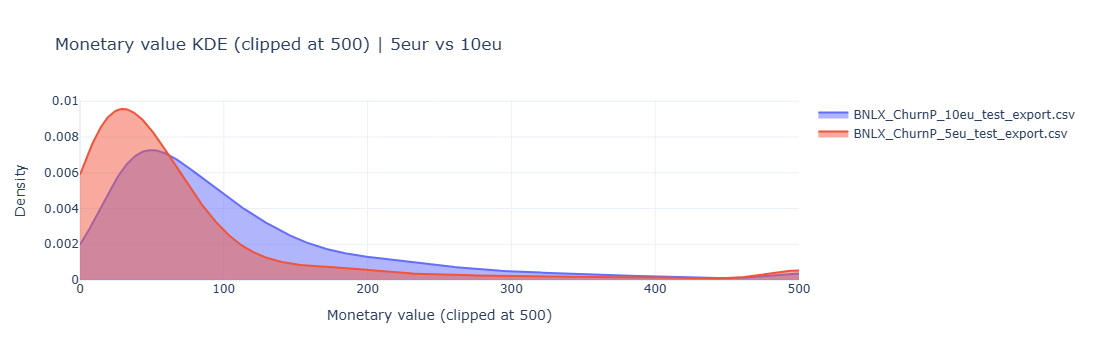

In [24]:
### Sanity check pattern we expec to see 5eu lower monetary value higher uplift, 10eu higher monetary value higher uplift
def plot_monetary_value_kde_top30(predicted_top30_per_treatment, clip_max=500):
    incentives = ["BNLX_ChurnP_5eu_test_export.csv", "BNLX_ChurnP_10eu_test_export.csv"]

    df_plot = predicted_top30_per_treatment.loc[
        predicted_top30_per_treatment["original_incentive_name"].isin(incentives),
        ["original_incentive_name", "monetary_value"]
    ].dropna(subset=["monetary_value"]).copy()

    df_plot["monetary_value"] = df_plot["monetary_value"].clip(upper=clip_max)

    x_grid = np.linspace(0, clip_max, 500)

    fig = go.Figure()

    for name, group in df_plot.groupby("original_incentive_name"):
        values = group["monetary_value"].values

        if len(values) < 2:
            continue

        kde = gaussian_kde(values)
        density = kde(x_grid)

        fig.add_trace(
            go.Scatter(
                x=x_grid,
                y=density,
                mode="lines",
                fill="tozeroy",
                name=name
            )
        )

    fig.update_layout(
        title=f"Monetary value KDE (clipped at {clip_max}) | 5eur vs 10eu",
        xaxis_title=f"Monetary value (clipped at {clip_max})",
        yaxis_title="Density",
        template="plotly_white"
    )

    fig.update_xaxes(range=[0, clip_max])

    fig.show()

plot_monetary_value_kde_top30(test_selected_binary_uplift, clip_max=500)

In [25]:
incentives = ["BNLX_ChurnP_5eu_test_export.csv", "BNLX_ChurnP_10eu_test_export.csv"]

df_plot = test_selected_binary_uplift.loc[
    test_selected_binary_uplift["original_incentive_name"].isin(incentives),
    ["original_incentive_name", "monetary_value"]
].dropna(subset=["monetary_value"]).copy()

In [26]:
df_plot.groupby('original_incentive_name')['monetary_value'].median()

original_incentive_name
BNLX_ChurnP_10eu_test_export.csv    79.0
BNLX_ChurnP_5eu_test_export.csv     44.5
Name: monetary_value, dtype: float64